# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
#Type your code here
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inisialisasi Struktur Folder
nama_siswa = "Imammul_Arif"
root_dir = f"Eksperimen_SML_{nama_siswa}"
preprocessing_dir = os.path.join(root_dir, "preprocessing")
raw_dir = os.path.join(root_dir, "dataset_heart_raw")

os.makedirs(preprocessing_dir, exist_ok=True)
os.makedirs(raw_dir, exist_ok=True)

# 2. Setup Logging (Untuk kriteria Monitoring & Logging)
log_path = os.path.join(root_dir, "experiment.log")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler(log_path), logging.StreamHandler()]
)

logging.info("Struktur folder dan sistem logging berhasil disiapkan.")

# Konfigurasi visualisasi
%matplotlib inline
sns.set(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
#Type your code here

# URL Dataset UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Memuat data
df = pd.read_csv(url, names=column_names, na_values='?')

# Simpan ke folder raw sesuai kriteria repositori
raw_file_path = os.path.join(raw_dir, "heart_disease_raw.csv")
df.to_csv(raw_file_path, index=False)

logging.info(f"Dataset dimuat dan disimpan di {raw_file_path}")
display(df.head())
df.info()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


/tmp/ipykernel_8461/2817094185.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


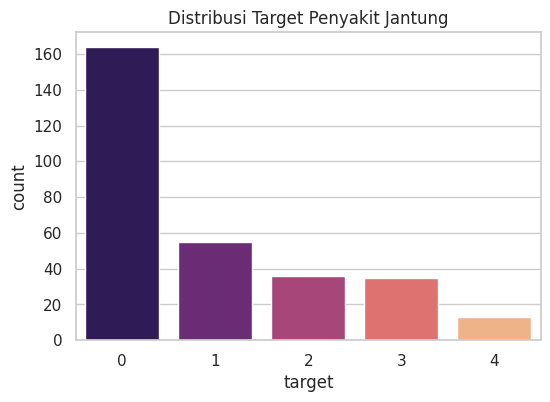

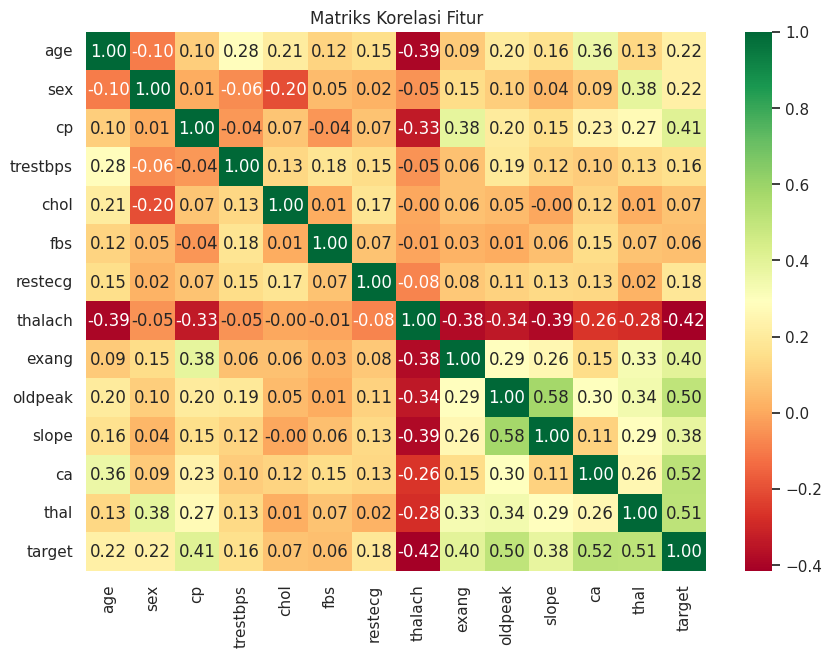

In [9]:
#Type your code here
logging.info("Memulai proses EDA.")

# 1. Statistik Deskriptif
display(df.describe())

# 2. Visualisasi Target
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='magma')
plt.title('Distribusi Target Penyakit Jantung')
plt.show()

# 3. Heatmap Korelasi
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriks Korelasi Fitur')
plt.show()

logging.info("EDA selesai divisualisasikan.")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# ==========================================
# 5. DATA PREPROCESSING (Tahap Akhir)
# ==========================================

logging.info("Memulai tahap akhir Data Preprocessing.")

# 1. Menangani Missing Values
# Berdasarkan EDA, kolom 'ca' dan 'thal' memiliki missing values (NaN)
# Kita isi dengan nilai yang paling sering muncul (Mode)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# 2. Menghapus Data Duplikat
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    logging.info(f"Ditemukan {duplicate_count} data duplikat. Menghapus duplikat...")
    df = df.drop_duplicates()
else:
    logging.info("Tidak ditemukan data duplikat.")

# 3. Menyimpan Dataset Hasil Preprocessing
# Sesuai kriteria folder: preprocessing/namadataset_preprocessing
processed_filename = "heart_disease_preprocessed.csv"
processed_path = os.path.join(preprocessing_dir, processed_filename)
df.to_csv(processed_path, index=False)

logging.info(f"Dataset hasil preprocessing disimpan di: {processed_path}")

# 4. Feature Selection & Target Transformation
# Memisahkan fitur (X) dan target (y)
# Karena dataset ini targetnya 0-4 (tingkat keparahan), kita ubah menjadi biner:
# 0 = Sehat, 1 = Sakit (semua nilai > 0 dianggap sakit)
X = df.drop('target', axis=1)
y = (df['target'] > 0).astype(int)

# 5. Membagi Data (Train-Test Split)
# Menggunakan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Standarisasi Fitur (Scaling)
# Agar model tidak bias karena rentang nilai yang berbeda (misal: Kolesterol vs Usia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logging.info("Preprocessing Selesai: Missing values ditangani, data disimpan, dan scaling berhasil dilakukan.")

# Menampilkan informasi akhir
print(f"File disimpan di: {processed_path}")
print(f"Ukuran Data Training: {X_train_scaled.shape}")
print(f"Ukuran Data Testing: {X_test_scaled.shape}")

File disimpan di: Eksperimen_SML_Imammul_Arif/preprocessing/heart_disease_preprocessed.csv
Ukuran Data Training: (242, 13)
Ukuran Data Testing: (61, 13)
